In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, matthews_corrcoef,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import KNNImputer
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [2]:
#LOAD DATA
df = pd.read_csv("gw_sanity.csv")
print(f"Original dataset shape: {df.shape}")

Original dataset shape: (42, 20)


In [3]:
# 2. COMPUTE WQI (BIS Standard)
# Fixed: 'conductivity' key now maps to correct column name

param_map = {
    'ph': 'ph',
    'turbidity': 'turbidity',
    'chloride': 'chloride_(ppm)',
    'sulphate': 'sulphates(ppm)',
    'nitrate': 'nitrate(ppm)',
    'iron': 'iron_(ppm)',
    'fluoride': 'fluorides(ppm)',
    'conductivity': 'conductivity'   # ← fixed typo ('conductiv' → 'conductivity')
}

def compute_bis_wqi(df):
    bis_limits = {
        "ph": (6.5, 8.5),
        "turbidity": 5,
        "chloride": 250,
        "sulphate": 200,
        "nitrate": 45,
        "fluoride": 1.5,
        "iron": 0.3,
        "conductivity": 2000
    }
    weights = {k: 1/v if not isinstance(v, tuple) else 1/v[1]
               for k, v in bis_limits.items()}
    wqi_vals = []
    for _, row in df.iterrows():
        num, den = 0, 0
        for p, limit in bis_limits.items():
            col = param_map[p]
            if col not in df.columns or pd.isna(row[col]):
                continue
            wi = weights[p]
            qi = abs(row[col] - 7.0) / (8.5 - 7.0) * 100 if p == 'ph' else (row[col] / limit) * 100
            num += wi * qi
            den += wi
        wqi_vals.append(num / den if den != 0 else np.nan)
    df = df.copy()
    df["wqi"] = wqi_vals
    return df

df = compute_bis_wqi(df)


Class distribution:
wqi_class
Poor          18
Unsuitable    11
Very Poor      9
Good           4
Name: count, dtype: int64


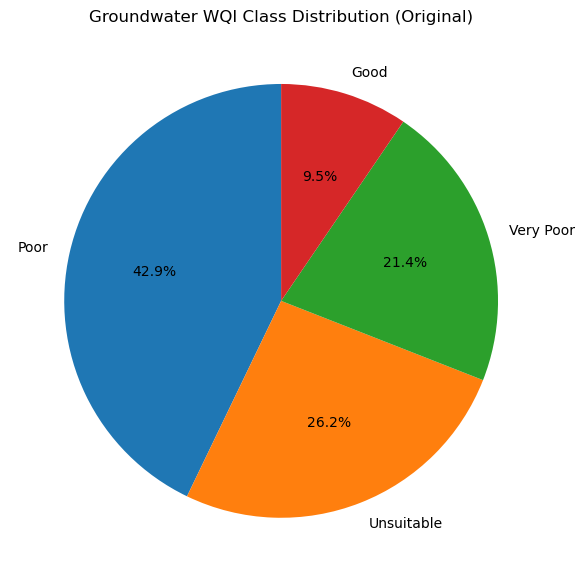

Saved: class_distribution.png


In [4]:
# 3. WQI CLASSIFICATION LABELS

def wqi_class(wqi):
    if wqi <= 50:   return "Excellent"
    elif wqi <= 100: return "Good"
    elif wqi <= 200: return "Poor"
    elif wqi <= 300: return "Very Poor"
    else:            return "Unsuitable"

df["wqi_class"] = df["wqi"].apply(wqi_class)

# Class distribution
print("\nClass distribution:")
print(df["wqi_class"].value_counts())

plt.figure(figsize=(6, 6))
df["wqi_class"].value_counts().plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Groundwater WQI Class Distribution (Original)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("Saved: class_distribution.png")

In [5]:
# 4. DROP USELESS / LEAKY COLUMNS

always_nan_cols = [col for col in df.columns if df[col].isna().all()]
print(f"\nDropping 100%-NaN columns: {always_nan_cols}")
df.drop(columns=always_nan_cols, inplace=True)

# iron_(ppm) → near-perfect correlation with WQI (it's in the WQI formula = leakage)
if 'iron_(ppm)' in df.columns:
    print("Dropping 'iron_(ppm)' — data leakage (directly used in WQI formula)")
    df.drop(columns=['iron_(ppm)'], inplace=True)


Dropping 100%-NaN columns: ['odour', 'lead(ppm)', 'pesticide_(µg/l)']
Dropping 'iron_(ppm)' — data leakage (directly used in WQI formula)


In [6]:
# 5. ENCODE TARGET

le = LabelEncoder()
df["wqi_encoded"] = le.fit_transform(df["wqi_class"])
class_names = le.classes_
print(f"\nClass encoding: {dict(zip(le.transform(class_names), class_names))}")


Class encoding: {0: 'Good', 1: 'Poor', 2: 'Unsuitable', 3: 'Very Poor'}


In [7]:
# 6. FEATURE / TARGET SPLIT

X = df.select_dtypes(include=[np.number]).drop(columns=["wqi", "wqi_encoded"])
y = df["wqi_encoded"]

print(f"\nFeatures: {list(X.columns)}")
print(f"Shape before augmentation: {X.shape}")
print(f"\nMissing values:\n{X.isna().sum().sort_values(ascending=False)}")


Features: ['year', 'ph', 'turbidity', 'conductivity', 'chloride_(ppm)', 'sulphates(ppm)', 'cod(ppm)', 'bod(ppm)', 'do(ppm)', 'ammonia(ppm)', 'nitrate(ppm)', 'fluorides(ppm)', 'phosphates(ppm)', 'total_bacterial_count_(cfu/ml)', 'total_fungal_count_(cfu/ml)']
Shape before augmentation: (42, 15)

Missing values:
phosphates(ppm)                   36
fluorides(ppm)                    27
total_fungal_count_(cfu/ml)       18
year                               0
ph                                 0
turbidity                          0
conductivity                       0
chloride_(ppm)                     0
sulphates(ppm)                     0
cod(ppm)                           0
bod(ppm)                           0
do(ppm)                            0
ammonia(ppm)                       0
nitrate(ppm)                       0
total_bacterial_count_(cfu/ml)     0
dtype: int64


In [8]:
#TRAIN-TEST SPLIT (stratified — before any augmentation)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")


Train: (33, 15), Test: (9, 15)


In [9]:
# 8. DATA AUGMENTATION (Gaussian noise — training set only)

def augment_data(X, y, n_copies=3, noise_fraction=0.01, random_state=42):
    """
    Create n_copies noisy versions of each training sample.
    Noise = Gaussian with std = noise_fraction * feature_std.
    Only applied to non-NaN values to preserve missing patterns.
    """
    rng = np.random.RandomState(random_state)
    feature_stds = X.std(skipna=True)
    X_list, y_list = [X.copy()], [y.copy()]
    for _ in range(n_copies):
        X_noisy = X.copy()
        for col in X.columns:
            std = feature_stds[col]
            if std == 0 or np.isnan(std):
                continue
            noise = rng.normal(0, noise_fraction * std, size=len(X))
            mask = X_noisy[col].notna()
            X_noisy.loc[mask, col] = X_noisy.loc[mask, col] + noise[mask]
        y_list.append(y.copy())
        X_list.append(X_noisy)
    return pd.concat(X_list, ignore_index=True), pd.concat(y_list, ignore_index=True)

X_train_aug, y_train_aug = augment_data(X_train, y_train, n_copies=3)
print(f"\nAfter Gaussian augmentation: train={X_train_aug.shape}")


After Gaussian augmentation: train=(132, 15)


In [11]:
#KNN IMPUTATION

imputer = KNNImputer(n_neighbors=5)
X_train_imp = imputer.fit_transform(X_train_aug)
X_test_imp  = imputer.transform(X_test)

In [12]:
#FEATURE SCALING

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

In [13]:
#SMOTE (on augmented + imputed + scaled training data)
#     Applied AFTER imputation/scaling to avoid NaN issues in SMOTE

print(f"\nClass distribution before SMOTE:\n{pd.Series(y_train_aug).value_counts()}")
smote = SMOTE(random_state=42, k_neighbors=min(5, pd.Series(y_train_aug).value_counts().min() - 1))
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train_aug)
print(f"Class distribution after SMOTE:\n{pd.Series(y_train_sm).value_counts()}")
print(f"Final training shape after SMOTE: {X_train_sm.shape}")


Class distribution before SMOTE:
wqi_encoded
1    56
2    36
3    28
0    12
Name: count, dtype: int64
Class distribution after SMOTE:
wqi_encoded
1    56
2    56
3    56
0    56
Name: count, dtype: int64
Final training shape after SMOTE: (224, 15)


In [14]:
# 12. HYPERPARAMETER TUNING (GridSearchCV)

print("\n--- Hyperparameter Tuning ---")

param_grids = {
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [None, 5, 10],
            "min_samples_split": [2, 5]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100],
            "learning_rate": [0.05, 0.1, 0.2],
            "max_depth": [3, 5]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(eval_metric="mlogloss", random_state=42, verbosity=0),
        "params": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5]
        }
    },
    "SVM": {
        "model": SVC(probability=True, random_state=42),
        "params": {
            "C": [1, 10, 100],
            "gamma": ["scale", "auto", 0.1],
            "kernel": ["rbf", "linear"]
        }
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7, 9],
            "weights": ["uniform", "distance"],
            "metric": ["euclidean", "manhattan"]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [None, 3, 5, 10],
            "min_samples_split": [2, 5, 10],
            "criterion": ["gini", "entropy"]
        }
    }
}

# StratifiedKFold — use 5-fold (safe for augmented set; 10-fold risks tiny folds)
kf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_models = {}
final_results = []

for name, cfg in param_grids.items():
    grid = GridSearchCV(cfg["model"], cfg["params"], cv=5,
                        scoring="f1_weighted", n_jobs=-1)
    grid.fit(X_train_sm, y_train_sm)
    best_model = grid.best_estimator_
    best_models[name] = best_model

    y_pred = best_model.predict(X_test_sc)

    acc       = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall    = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1        = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    mcc       = matthews_corrcoef(y_test, y_pred)

    # CV on SMOTE training data (fixed bug: was computed before loop)
    cv5 = cross_val_score(best_model, X_train_sm, y_train_sm, cv=kf5, scoring="accuracy")

    print(f"{name}: Acc={acc:.3f} | F1={f1:.3f} | Best params: {grid.best_params_}")

    final_results.append([
        name,
        round(acc, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4),
        round(mcc, 4),
        f"{cv5.mean():.3f} ± {cv5.std():.3f}"
    ])


--- Hyperparameter Tuning ---
Random Forest: Acc=0.889 | F1=0.877 | Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Gradient Boosting: Acc=0.778 | F1=0.689 | Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
XGBoost: Acc=0.667 | F1=0.585 | Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
SVM: Acc=0.889 | F1=0.877 | Best params: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
KNN: Acc=1.000 | F1=1.000 | Best params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Decision Tree: Acc=0.778 | F1=0.689 | Best params: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}


In [15]:
# 13. RESULTS TABLE

columns = ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "MCC", "5-Fold CV Acc"]
results_df = pd.DataFrame(final_results, columns=columns)
results_df = results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

print("\n=== FINAL CLASSIFICATION RESULTS ===")
print(results_df.to_string(index=False))


=== FINAL CLASSIFICATION RESULTS ===
            Model  Accuracy  Precision  Recall  F1 Score    MCC 5-Fold CV Acc
              KNN    1.0000     1.0000  1.0000    1.0000 1.0000 0.987 ± 0.027
    Random Forest    0.8889     0.9111  0.8889    0.8765 0.8504 1.000 ± 0.000
              SVM    0.8889     0.9111  0.8889    0.8765 0.8504 0.991 ± 0.018
Gradient Boosting    0.7778     0.6296  0.7778    0.6889 0.7184 1.000 ± 0.000
    Decision Tree    0.7778     0.6296  0.7778    0.6889 0.7184 0.987 ± 0.011
          XGBoost    0.6667     0.5259  0.6667    0.5852 0.5320 0.987 ± 0.018


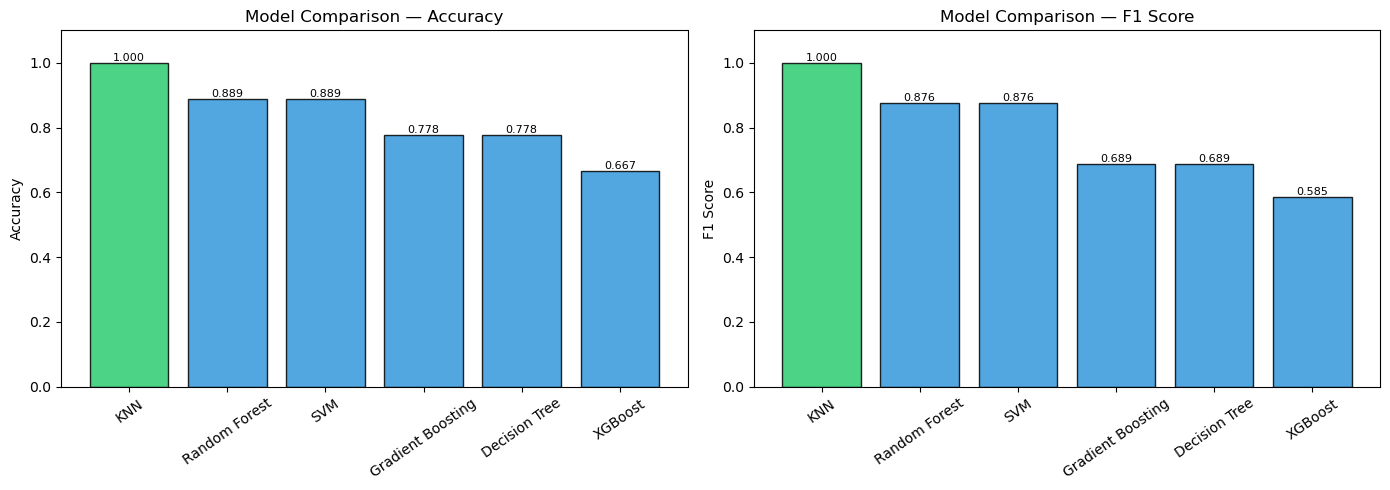

Saved: model_comparison.png

=== Classification Report: KNN ===
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00         1
        Poor       1.00      1.00      1.00         4
  Unsuitable       1.00      1.00      1.00         2
   Very Poor       1.00      1.00      1.00         2

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



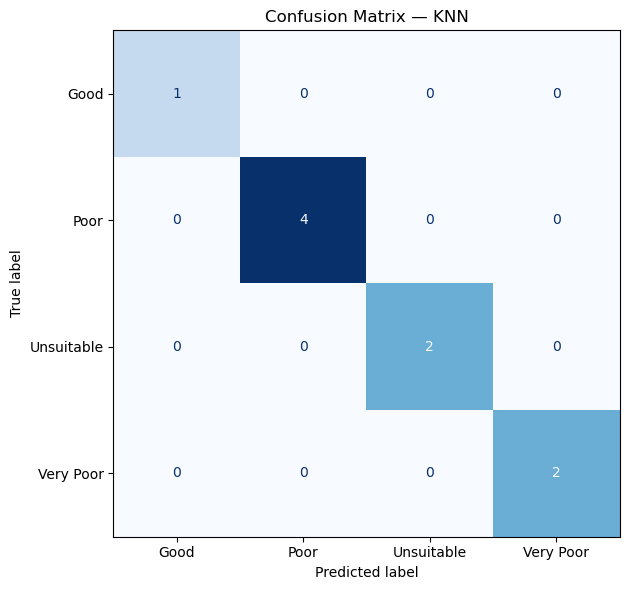

Saved: confusion_matrix.png


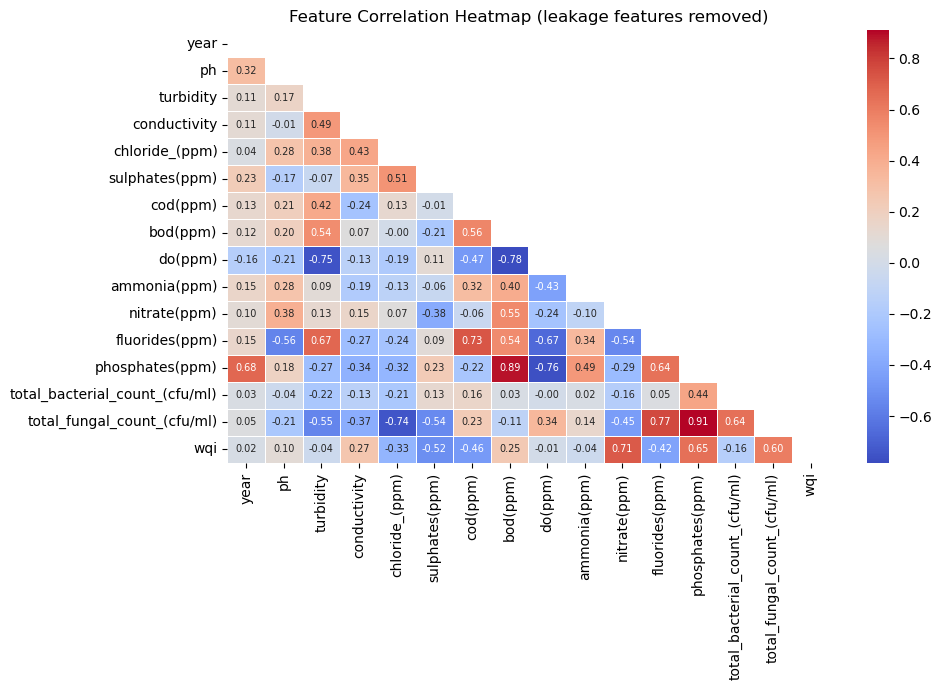

Saved: correlation_heatmap.png


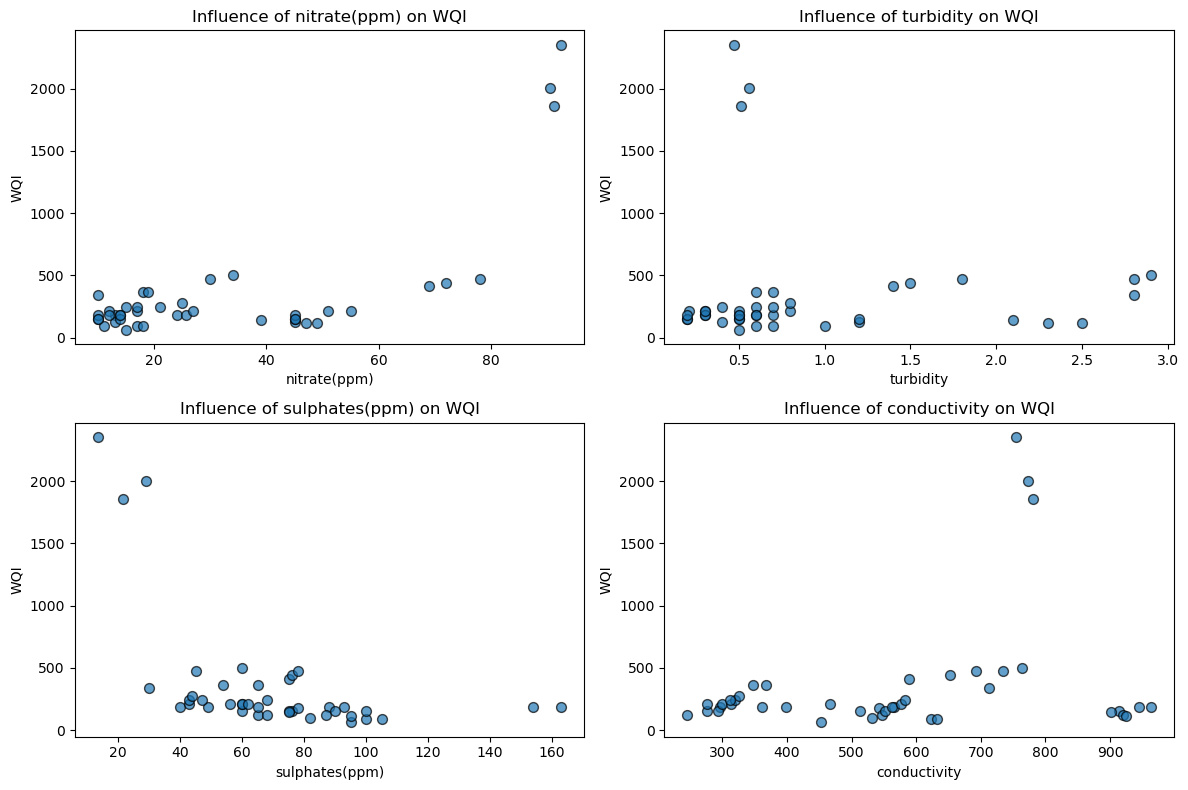

Saved: parameter_influence.png


In [16]:
# 14. PLOTS
# ─────────────────────────────────────────────
# Model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics = ["Accuracy", "F1 Score"]
colors = [["#3498db", "#2ecc71", "#e74c3c", "#9b59b6", "#f39c12", "#1abc9c"]] * 2

for ax, metric in zip(axes, metrics):
    bars = ax.bar(results_df["Model"], results_df[metric],
                  color=["#2ecc71" if v == results_df[metric].max() else "#3498db"
                         for v in results_df[metric]],
                  edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=8)
    ax.set_title(f"Model Comparison — {metric}")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()
print("Saved: model_comparison.png")

# Confusion matrix — best model
best_name = results_df.iloc[0]["Model"]
best_model = best_models[best_name]
y_pred_best = best_model.predict(X_test_sc)

print(f"\n=== Classification Report: {best_name} ===")
print(classification_report(y_test, y_pred_best, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_test, y_pred_best)
# Only show classes present in test set
present_labels = sorted(y_test.unique())
present_class_names = [class_names[i] for i in present_labels]

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present_class_names)
disp.plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include="number").drop(columns=["wqi_encoded"]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            annot_kws={"size": 7}, linewidths=0.4)
plt.title("Feature Correlation Heatmap (leakage features removed)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()
print("Saved: correlation_heatmap.png")

# Parameter influence scatter plots
scatter_params = ["nitrate(ppm)", "turbidity", "sulphates(ppm)", "conductivity"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, param in zip(axes.flat, scatter_params):
    if param in df.columns:
        ax.scatter(df[param], df["wqi"], alpha=0.7, edgecolors='black', s=50)
        ax.set_xlabel(param)
        ax.set_ylabel("WQI")
        ax.set_title(f"Influence of {param} on WQI")
plt.tight_layout()
plt.savefig("parameter_influence.png", dpi=150)
plt.show()
print("Saved: parameter_influence.png")

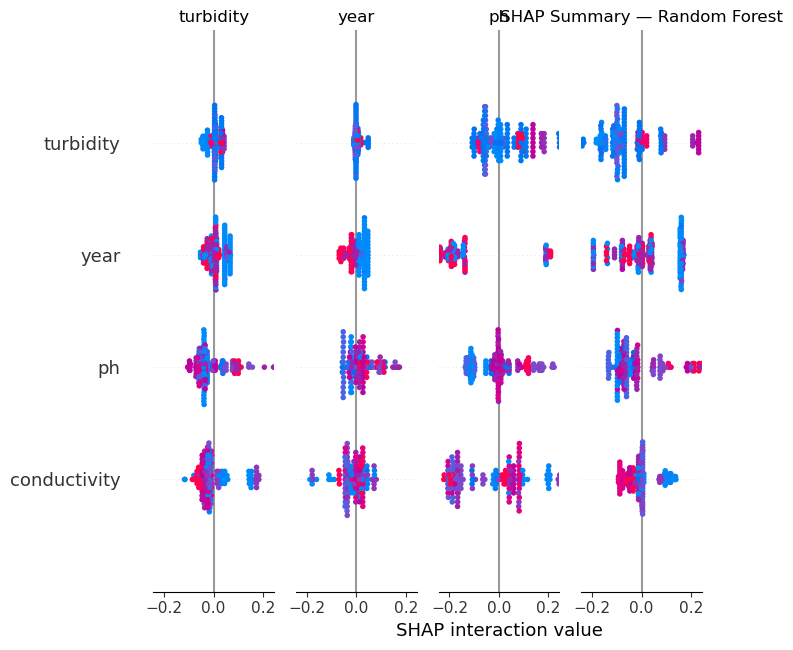

Saved: shap_summary.png

 Done! Best model: KNN
Model                      KNN
Accuracy                   1.0
Precision                  1.0
Recall                     1.0
F1 Score                   1.0
MCC                        1.0
5-Fold CV Acc    0.987 ± 0.027
Name: 0, dtype: object


In [17]:
# 15. SHAP ANALYSIS (best tree-based model)

try:
    import shap

    # Use a tree-based model for SHAP TreeExplainer
    shap_model_name = None
    for preferred in ["Random Forest", "Gradient Boosting", "XGBoost", "Decision Tree"]:
        if preferred in best_models:
            shap_model_name = preferred
            break

    shap_model = best_models[shap_model_name]
    feature_names = list(X.columns)

    explainer = shap.TreeExplainer(shap_model)
    # Use a sample of SMOTE data for SHAP (large dataset → sample for speed)
    shap_sample = X_train_sm[:200] if len(X_train_sm) > 200 else X_train_sm
    shap_values = explainer.shap_values(shap_sample)

    # Multi-class SHAP: plot mean abs importance
    if isinstance(shap_values, list):
        # shap_values is list of arrays (one per class)
        mean_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0)
        plt.figure(figsize=(8, 5))
        mean_importance = mean_shap.mean(axis=0)
        sorted_idx = np.argsort(mean_importance)[::-1]
        plt.barh([feature_names[i] for i in sorted_idx],
                 mean_importance[sorted_idx], color='steelblue')
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"SHAP Feature Importance — {shap_model_name}")
        plt.tight_layout()
        plt.savefig("shap_importance.png", dpi=150)
        plt.show()
        print("Saved: shap_importance.png")
    else:
        shap.summary_plot(shap_values, shap_sample, feature_names=feature_names, show=False)
        plt.title(f"SHAP Summary — {shap_model_name}")
        plt.tight_layout()
        plt.savefig("shap_summary.png", dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: shap_summary.png")

except ImportError:
    print("SHAP not installed. Run: pip install shap")

print(f"\n Done! Best model: {best_name}")
print(results_df.iloc[0])